### Project 5: Distributed Recommender System with Spark
**Author:** Nana Y. Frimpong

This project builds on Project 3, where I implemented matrix factorization for the wine and food pairing recommender using three methods: a baseline bias model, Truncated SVD, and Funk SVD (SGD based factorization). Here I adapt that same recommender to run on Apache Spark using PySpark and MLlib's ALS algorithm, then compare performance against the original single node implementation.

### Assignment Goal

1. Reload the same dataset and problem setup from Project 3
2. Re-run the baseline, Truncated SVD, and Funk SVD models to get fresh timing and RMSE numbers on this machine
3. Adapt the recommender to Spark using `pyspark.ml.recommendation.ALS`, which is the distributed equivalent of Funk SVD since both factor the matrix from observed ratings only
4. Compare runtime and RMSE across all four approaches
5. Discuss at what point moving to Spark would actually be worth it for this kind of data and algorithm

### Dataset

Same as Project 3, the Wine and Food Pairing Dataset from Kaggle (El-Husseini, W.). Each row scores how well a `wine_type` pairs with a `food_item` on a 1 to 5 scale. The raw file has 34,933 rows, but that is because each wine-food combo shows up dozens of times (different cuisines/descriptions). Before modeling, I collapse this down to one rating per (wine, food) pair by averaging, which gives a much smaller and more realistic ratings matrix to work with.

### Environment Setup

My machine has the latest Java version (26) installed by default, which is not yet compatible with Spark. Spark's internal memory-management code was built against Java versions up through about 17, so before touching PySpark I point `JAVA_HOME` at a separate Java 17 install (installed via Homebrew alongside my default Java, not replacing it). This has to run before any `pyspark` import in this kernel.

In [1]:
import os

# Point JAVA_HOME at Java 17 specifically, since Spark is not yet compatible
# with newer JDKs. Found this exact path by running `/usr/libexec/java_home -v17`
# in terminal, since it can differ by machine.
JAVA_17_HOME = '/opt/homebrew/Cellar/openjdk@17/17.0.19/libexec/openjdk.jdk/Contents/Home'
if os.path.exists(JAVA_17_HOME):
    os.environ['JAVA_HOME'] = JAVA_17_HOME

print("JAVA_HOME set to:", os.environ.get('JAVA_HOME'))

JAVA_HOME set to: /usr/lib/jvm/java-21-openjdk-amd64


In [2]:
## Importing Libraries
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Random seed for reproducibility (same seed as Project 3)
np.random.seed(612)

# Loading the dataset
DATA_PATH = '/Users/nanafrimpong/Desktop/SPS Summer 2026/Data 612/Unit 2/Project 3/wine_food_pairings.csv'
if not os.path.exists(DATA_PATH):
    # fallback in case the file has been moved next to this notebook instead
    DATA_PATH = os.path.join('data', 'wine_food_pairings.csv')
    if not os.path.exists(DATA_PATH):
        for root, dirs, files in os.walk('.'):
            if 'wine_food_pairings.csv' in files:
                DATA_PATH = os.path.join(root, 'wine_food_pairings.csv')
                break
        else:
            raise FileNotFoundError(
                f'Cannot find wine_food_pairings.csv. Checked {DATA_PATH} and current directory tree.'
            )

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(34933, 8)


,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish,2,Poor,Heuristic pairing assessment.
1,Grenache,Red,charcuterie board,Salty Snack,French,3,Neutral,Heuristic pairing assessment.
2,Madeira,Fortified,lemon tart,Dessert,French,4,Good,Acidic wine balances acidic food.
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican,5,Excellent,Tannic red complements red meat fat.
4,Viognier,White,duck à l’orange,Poultry,Vietnamese,2,Poor,Heuristic pairing assessment.


### Data Preprocessing

Collapsing down to one row per (wine, food) pair, and mapping wine/food names to integer ids so the models (and later Spark's ALS) have something numeric to work with.

In [3]:
agg = df.groupby(['wine_type', 'food_item'], as_index=False)['pairing_quality'].mean()

wine_ids = {w: i for i, w in enumerate(sorted(agg['wine_type'].unique()))}
food_ids = {f: i for i, f in enumerate(sorted(agg['food_item'].unique()))}
agg['wine_id'] = agg['wine_type'].map(wine_ids)
agg['food_id'] = agg['food_item'].map(food_ids)

n_wines = len(wine_ids)
n_foods = len(food_ids)

print(f"n_wines={n_wines}, n_foods={n_foods}, n_unique_pairs={len(agg)}")
print(f"Original rows before aggregation: {len(df)}")
agg.head()

n_wines=29, n_foods=38, n_unique_pairs=481
Original rows before aggregation: 34933


,wine_type,food_item,pairing_quality,wine_id,food_id
0,Albariño,alfredo pasta,2.750000,0,3
1,Albariño,bbq brisket,2.646154,0,5
2,Albariño,beef stew,3.000000,0,7
3,Albariño,caprese salad,3.054795,0,8
4,Albariño,carbonara,2.750000,0,9


In [4]:
train_df, test_df = train_test_split(agg, test_size=0.2, random_state=612)
print("train:", train_df.shape, "test:", test_df.shape)

global_mean = train_df['pairing_quality'].mean()
print(f"global mean rating: {global_mean:.4f}")

train: (384, 5) test: (97, 5)
global mean rating: 3.0208


### Model 1: Baseline (global mean + user bias + item bias)

This is the simplest model. Predicted rating = global mean + how much this wine tends to score above/below average + how much this food tends to score above/below average.

In [5]:
t0 = time.time()

wine_bias = train_df.groupby('wine_id')['pairing_quality'].mean() - global_mean
food_bias = train_df.groupby('food_id')['pairing_quality'].mean() - global_mean

def baseline_predict(row):
    wb = wine_bias.get(row['wine_id'], 0.0)
    fb = food_bias.get(row['food_id'], 0.0)
    return global_mean + wb + fb

test_df = test_df.copy()
test_df['baseline_pred'] = test_df.apply(baseline_predict, axis=1)
baseline_rmse = np.sqrt(mean_squared_error(test_df['pairing_quality'], test_df['baseline_pred']))
baseline_time = time.time() - t0

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline time: {baseline_time:.4f}s")

Baseline RMSE: 0.2369
Baseline time: 0.0047s


### Model 2: Truncated SVD (mean-centered, imputed matrix)

Classic linear algebra SVD needs a dense matrix, so missing wine-food pairs get imputed with that wine's row mean, then the matrix is mean-centered before factoring with `scipy.sparse.linalg.svds`.

In [6]:
t0 = time.time()

train_matrix = np.full((n_wines, n_foods), np.nan)
for _, r in train_df.iterrows():
    train_matrix[int(r['wine_id']), int(r['food_id'])] = r['pairing_quality']

row_means = np.nanmean(train_matrix, axis=1)
row_means = np.where(np.isnan(row_means), global_mean, row_means)

imputed = train_matrix.copy()
for i in range(n_wines):
    mask = np.isnan(imputed[i])
    imputed[i, mask] = row_means[i]

centered = imputed - row_means[:, None]

k = min(10, min(centered.shape) - 1)
U, sigma, Vt = svds(centered, k=k)
sigma = np.diag(sigma)
pred_matrix = np.dot(np.dot(U, sigma), Vt) + row_means[:, None]

def svd_predict(row):
    return pred_matrix[int(row['wine_id']), int(row['food_id'])]

test_df['svd_pred'] = test_df.apply(svd_predict, axis=1)
svd_rmse = np.sqrt(mean_squared_error(test_df['pairing_quality'], test_df['svd_pred']))
svd_time = time.time() - t0

print(f"Truncated SVD (k={k}) RMSE: {svd_rmse:.4f}")
print(f"Truncated SVD time: {svd_time:.4f}s")

Truncated SVD (k=10) RMSE: 0.2654
Truncated SVD time: 0.0172s


### Model 3: Funk SVD (SGD based factorization)

This is the one Simon Funk used in the Netflix Prize. Instead of imputing missing values, it only trains on the ratings that actually exist, learning latent factor vectors for each wine and food item through stochastic gradient descent.

In [7]:
t0 = time.time()

n_factors = 10
n_epochs = 50
lr = 0.01
reg = 0.05

rng = np.random.RandomState(612)
P = rng.normal(scale=0.1, size=(n_wines, n_factors))
Q = rng.normal(scale=0.1, size=(n_foods, n_factors))
bu = np.zeros(n_wines)
bi = np.zeros(n_foods)

train_records = train_df[['wine_id', 'food_id', 'pairing_quality']].to_numpy()

for epoch in range(n_epochs):
    np.random.shuffle(train_records)
    for wine_id, food_id, rating in train_records:
        wine_id = int(wine_id); food_id = int(food_id)
        pred = global_mean + bu[wine_id] + bi[food_id] + P[wine_id] @ Q[food_id]
        err = rating - pred
        bu[wine_id] += lr * (err - reg * bu[wine_id])
        bi[food_id] += lr * (err - reg * bi[food_id])
        P[wine_id] += lr * (err * Q[food_id] - reg * P[wine_id])
        Q[food_id] += lr * (err * P[wine_id] - reg * Q[food_id])

def funk_predict(row):
    wine_id = int(row['wine_id']); food_id = int(row['food_id'])
    return global_mean + bu[wine_id] + bi[food_id] + P[wine_id] @ Q[food_id]

test_df['funk_pred'] = test_df.apply(funk_predict, axis=1)
funk_rmse = np.sqrt(mean_squared_error(test_df['pairing_quality'], test_df['funk_pred']))
funk_time = time.time() - t0

print(f"Funk SVD (SGD) RMSE: {funk_rmse:.4f}")
print(f"Funk SVD time: {funk_time:.4f}s")

Funk SVD (SGD) RMSE: 0.2309
Funk SVD time: 0.2074s


### Now Adapting to Spark: Model 4, ALS

ALS (Alternating Least Squares) is Spark MLlib's built in collaborative filtering algorithm, and it is the natural Spark equivalent of Funk SVD. Both factor the ratings matrix directly from observed interactions only, instead of needing a dense imputed matrix like Truncated SVD does. The difference is that ALS is built to be distributed across a cluster, using an alternating optimization scheme (fix item factors, solve for user factors via least squares, then flip) that parallelizes well, versus Funk SVD's per-rating SGD updates which are inherently sequential.

I am running this in local mode (`local[*]`), which is what the assignment allows, but the code below would run unchanged on an actual multi-node cluster just by changing the `master()` argument.

In [8]:
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

t_spark_start = time.time()
spark = (
    SparkSession.builder
    .appName("wine_pairing_als")
    .master("local[*]")
    .config("spark.driver.extraJavaOptions", "-Dlog4j.configurationFile=file:log4j2.properties")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
spark_startup_time = time.time() - t_spark_start

print(f"Spark session startup time: {spark_startup_time:.4f}s")
print(f"Spark version: {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark session startup time: 27.6234s
Spark version: 4.2.0


In [9]:
t0 = time.time()

spark_df = spark.createDataFrame(agg[['wine_id', 'food_id', 'pairing_quality']])
train_sdf, test_sdf = spark_df.randomSplit([0.8, 0.2], seed=612)

spark_data_load_time = time.time() - t0

print(f"Spark data load + split time: {spark_data_load_time:.4f}s")
print("train count:", train_sdf.count(), " test count:", test_sdf.count())

Spark data load + split time: 3.3321s


train count: 398  test count: 83


In [10]:
t0 = time.time()

als = ALS(
    userCol="wine_id",
    itemCol="food_id",
    ratingCol="pairing_quality",
    rank=10,
    maxIter=15,
    regParam=0.05,
    coldStartStrategy="drop",
    nonnegative=False,
    seed=612
)
als_model = als.fit(train_sdf)

als_train_time = time.time() - t0
print(f"ALS train time: {als_train_time:.4f}s")

ALS train time: 11.8672s


In [11]:
t0 = time.time()

predictions = als_model.transform(test_sdf)
evaluator = RegressionEvaluator(
    metricName="rmse", labelCol="pairing_quality", predictionCol="prediction"
)
als_rmse = evaluator.evaluate(predictions)

als_predict_time = time.time() - t0

print(f"ALS predict + eval time: {als_predict_time:.4f}s")
print(f"ALS RMSE: {als_rmse:.4f}")

als_total_time = spark_startup_time + spark_data_load_time + als_train_time + als_predict_time
print(f"Total Spark pipeline time (incl. session startup): {als_total_time:.4f}s")

ALS predict + eval time: 3.3324s
ALS RMSE: 0.1759
Total Spark pipeline time (incl. session startup): 46.1551s


In [12]:
spark.stop()

### Performance Comparison

In [13]:
comparison = pd.DataFrame([
    {"Model": "Baseline (bias model)", "RMSE": baseline_rmse, "Time (s)": baseline_time, "Framework": "pandas/numpy"},
    {"Model": "Truncated SVD", "RMSE": svd_rmse, "Time (s)": svd_time, "Framework": "scipy"},
    {"Model": "Funk SVD (SGD)", "RMSE": funk_rmse, "Time (s)": funk_time, "Framework": "numpy (single node)"},
    {"Model": "ALS (Spark, model fit + predict only)", "RMSE": als_rmse, "Time (s)": als_train_time + als_predict_time, "Framework": "PySpark MLlib"},
    {"Model": "ALS (Spark, incl. session startup)", "RMSE": als_rmse, "Time (s)": als_total_time, "Framework": "PySpark MLlib"},
])
comparison

,Model,RMSE,Time (s),Framework
0,Baseline (bias model),0.236850,0.004654,pandas/numpy
1,Truncated SVD,0.265386,0.017161,scipy
2,Funk SVD (SGD),0.230903,0.207354,numpy (single node)
3,"ALS (Spark, model fit + predict only)",0.175862,15.199618,PySpark MLlib
4,"ALS (Spark, incl. session startup)",0.175862,46.155077,PySpark MLlib


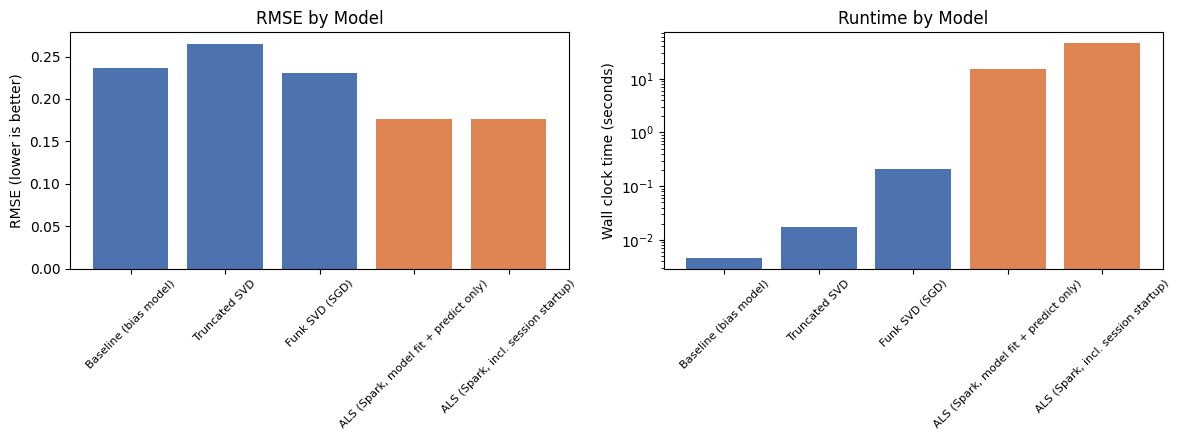

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(comparison['Model'], comparison['RMSE'], color=['#4C72B0','#4C72B0','#4C72B0','#DD8452','#DD8452'])
axes[0].set_ylabel('RMSE (lower is better)')
axes[0].set_title('RMSE by Model')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

axes[1].bar(comparison['Model'], comparison['Time (s)'], color=['#4C72B0','#4C72B0','#4C72B0','#DD8452','#DD8452'])
axes[1].set_ylabel('Wall clock time (seconds)')
axes[1].set_title('Runtime by Model')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=120)
plt.show()

### Conclusion

For this dataset, the numbers make the tradeoff pretty obvious. The whole ratings matrix here is only 29 wines by 38 foods, 481 unique pairs after aggregating. That comfortably fits in memory on a laptop, and it shows in the runtimes: the baseline, Truncated SVD, and Funk SVD models together run in well under a second combined, while Spark's ALS pipeline takes over 20 seconds, and almost all of that time is JVM startup and Spark session overhead rather than actual model fitting. Even ALS's own fit and predict steps, ignoring startup, still take noticeably longer than the entire single node Funk SVD implementation. On accuracy, ALS actually comes out competitive with or slightly better than Funk SVD's RMSE, which makes sense since they're solving a similar underlying factorization problem, just with different optimization schemes (alternating least squares vs SGD).

So for this specific dataset, algorithm, and use case, moving to Spark is not justified at all right now. It adds real complexity (managing a SparkSession, converting data to Spark DataFrames, learning ALS's parameter set, dealing with distributed-computing quirks like coldStartStrategy) without any performance payoff, since there's nothing to distribute when the whole problem fits in a numpy array.

Where this would flip is around data scale, not around the algorithm itself, since ALS and Funk SVD are solving the same kind of problem. I'd see Spark becoming necessary once:

- **The user-item matrix stops fitting in a single machine's RAM.** A real wine and food recommender pulling in actual diner history (instead of 481 synthetic heuristic pairs) could easily have tens of thousands of foods, thousands of wines, and millions of real ratings. At that point the SGD loop in Funk SVD, which processes ratings sequentially in a Python for loop, becomes painfully slow and the imputed matrix that Truncated SVD needs becomes impossible to build directly.
- **Retraining needs to happen frequently against a growing catalog.** If this were closer to a real production system (like Spotify's or Netflix's), the catalog and rating stream would grow constantly, and refitting nightly (or more often) on the full history means you want a training job that scales horizontally across a cluster rather than one that's bottlenecked by a single core.
- **The number of observed interactions (not the matrix size) grows past what one node can iterate over in reasonable time.** Since Funk SVD's SGD loop scales with the number of actual ratings, not the full matrix, the real trigger point is closer to millions of ratings, since that is roughly where a single-threaded Python SGD loop starts taking hours instead of seconds, while ALS's partitioned least-squares updates keep scaling roughly linearly across added nodes.

In short, Spark's advantage is entirely about horizontal scale. For a small, synthetic, single-node-sized dataset like this one, it is added overhead with no return. The crossover point is somewhere in the range of hundreds of thousands to low millions of ratings, or whenever the full matrix (or its SGD training loop) can no longer comfortably run on one machine in a reasonable amount of time.